Project - Predictive Maintenance for Industrial Equipment 

IMPORT IMPORTANT MODULES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix ,ConfusionMatrixDisplay ,classification_report, accuracy_score ,recall_score ,precision_score ,f1_score)
import warnings
warnings.filterwarnings("ignore")

IMPORTING DATA SET

In [2]:
data=pd.read_csv('C:/Users/abshi/OneDrive/Desktop/Data Analyst/datasets/predictive_maintenance.csv')
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


CHECKING FOR NULL AND DUPLICATE VALUES

In [3]:
n = data.shape[0]
print('Features non-null values and data type:')
data.info()
print('Check for duplicate values:',
      data['Product ID'].unique().shape[0]!=n)

Features non-null values and data type:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
Check for duplicate values: False


NOTE:-

There is no missing data

There are no duplicate values

Six columns are numerical features, including UDI

Three columns are categorical features, including ProductID.

In [4]:
#drop Unimportant colums
data.drop(["UDI" ,"Product ID"] , axis =1  , inplace =True)
data.sample()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
1228,M,297.1,308.4,1583,38.2,150,0,No Failure


EXPLORATORY DATA ANALYSIS

In [5]:
#Numerical Colums
data.select_dtypes(["float","int"])

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0
9996,298.9,308.4,1632,31.8,17,0
9997,299.0,308.6,1645,33.4,22,0
9998,299.0,308.7,1408,48.5,25,0


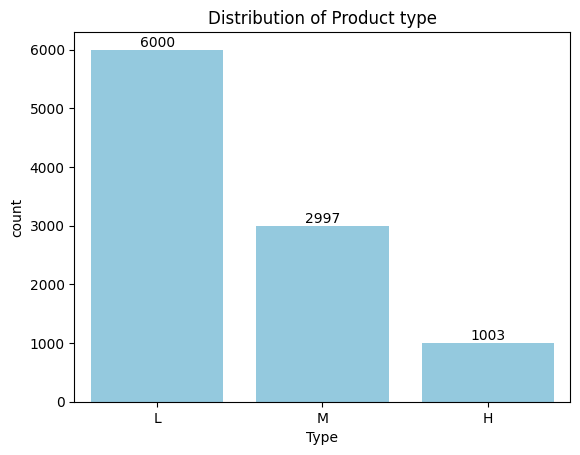

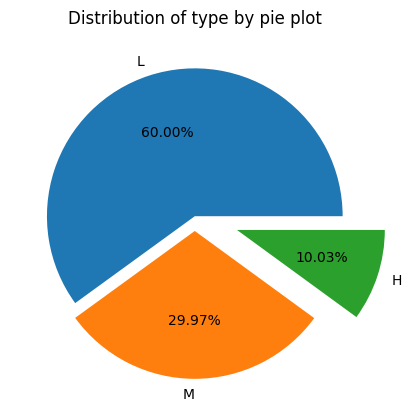

In [6]:
# Distributio of product type

figure=sns.countplot(x=data['Type'],data=data,order=["L", "M", "H"],color='skyblue')
for container in figure.containers:
    figure.bar_label(container)
plt.title('Distribution of Product type')
plt.show()

print('\n')

plt.pie(x=data.Type.value_counts().values, labels=data.Type.value_counts().index, autopct='%1.2f%%', explode=[0, 0.1, 0.3])
plt.title('Distribution of type by pie plot')
plt.show()

NOTE:-
1. There are 6000 (60.00%) low quality products, 2997 (29.97%) medium quality products and 1003 (10.03%) low quality products

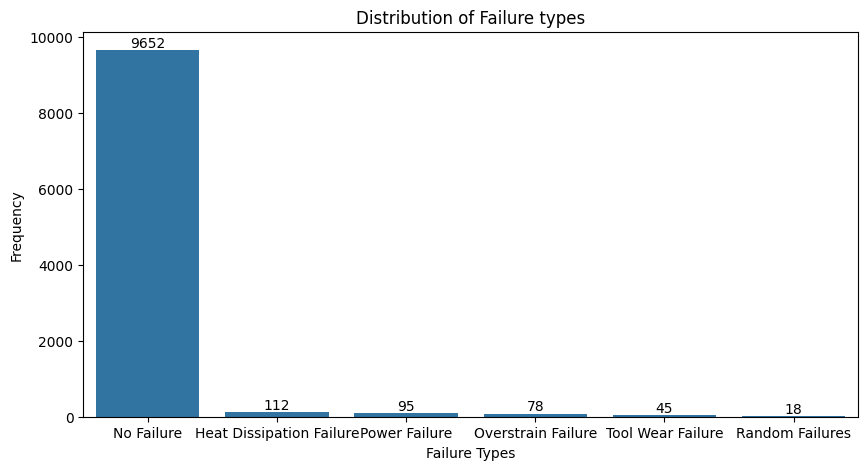

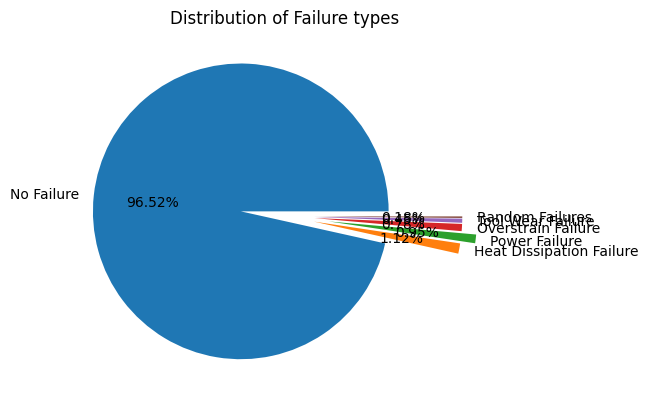

In [7]:
# Distribution of Failure types
plt.figure(figsize=(10,5))
fig1=sns.countplot(x=data["Failure Type"] ,order=data["Failure Type"].value_counts().index)
for container in fig1.containers:
    fig1.bar_label(container)
plt.title('Distribution of Failure types')
plt.xlabel('Failure Types')
plt.ylabel('Frequency')
plt.show()

print('\n')

plt.pie(x=data["Failure Type"].value_counts().values,labels=data["Failure Type"].value_counts().index,autopct='%1.2f%%', explode=[.3, 0.2, 0.3 ,.2 ,.2,0.2])
plt.title('Distribution of Failure types')
plt.show()

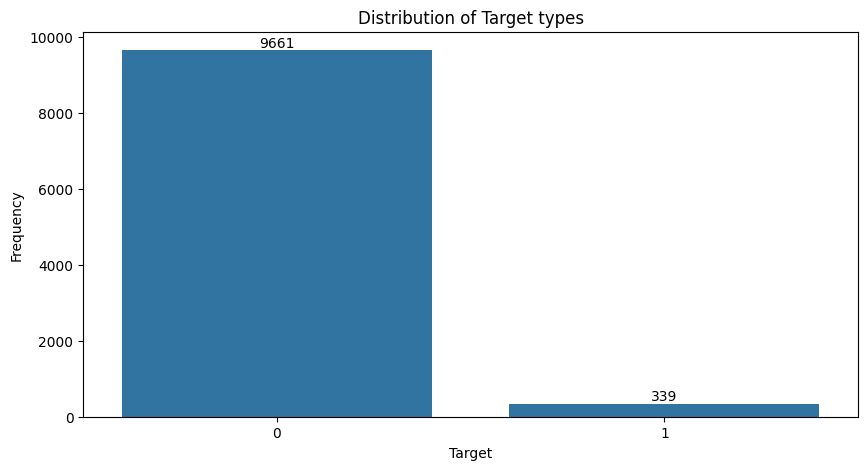

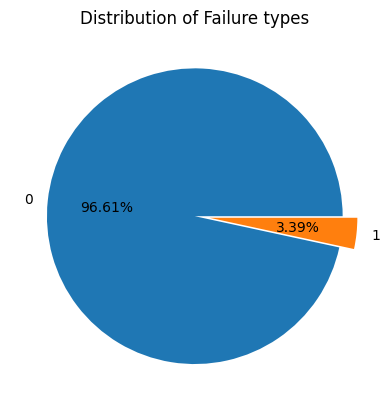

In [8]:
# Distribution of target
plt.figure(figsize=(10,5))
fig1=sns.countplot(x=data["Target"] ,order=data["Target"].value_counts().index)
for container in fig1.containers:
    fig1.bar_label(container)
plt.title('Distribution of Target types')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

print('\n')

plt.pie(x=data["Target"].value_counts().values,labels=data["Target"].value_counts().index,autopct='%1.2f%%', explode=[0,.1])
plt.title('Distribution of Failure types')
plt.show()

NOTE:-
There are total 339 (3.39%) failures and 9661 (96.61%) no failures

<Figure size 2000x2000 with 0 Axes>

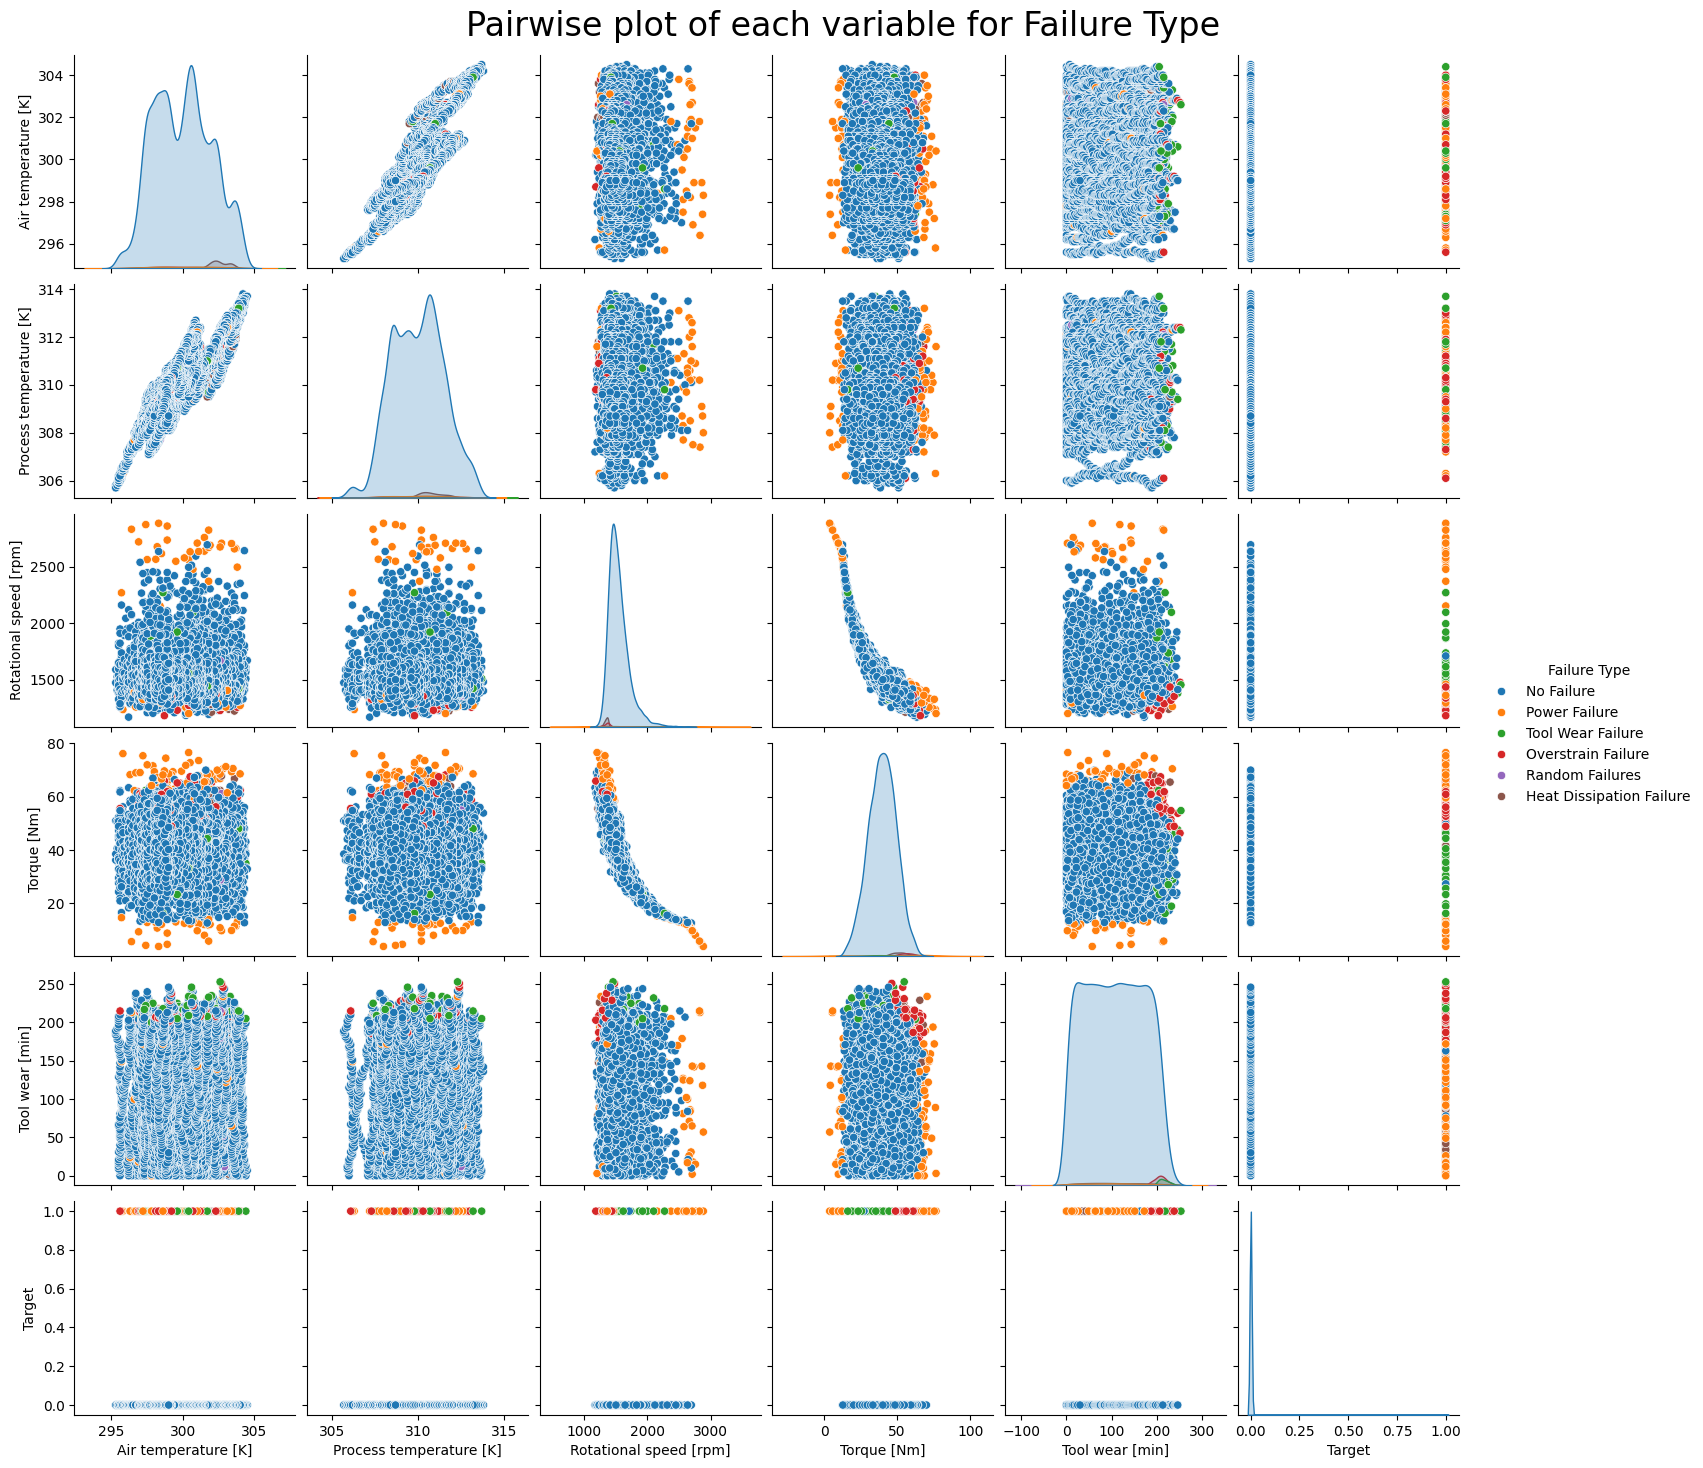

In [9]:
# Pairwise plot
plt.figure(figsize=(20,20))
pairplot = sns.pairplot(data=data, hue="Failure Type")
pairplot.fig.suptitle('Pairwise plot of each variable for Failure Type', fontsize=24) 
pairplot.fig.subplots_adjust(top=0.95)  
plt.show()

In [10]:
#summary Statistic
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Target,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


NOTE:-
1. Air temperature [K], Process temperature [K] don't have much deviation implies they don't have many outliers
2. Rotational speed [rpm], Torque [Nm], Tool wear [min] show significant deviation implies there lies the outliers	

In [11]:
# remove data with contradictory target and failure type variables
data.drop(data[(data['Target'] == 1) & (data['Failure Type'] == 'No Failure')].index, inplace=True)
data.drop(data[(data['Target'] == 0) & (data['Failure Type'] != 'No Failure')].index, inplace=True)

In [12]:
data.shape

(9973, 8)

In [13]:
# Encoding the varibles to integers
data['Type'].replace({'L':1,'M':2,'H':3},inplace=True)
data['Failure Type'].replace({'No Failure': 0,'Heat Dissipation Failure': 1,'Power Failure': 2,'Overstrain Failure': 3,'Tool Wear Failure': 4},inplace=True)

In [14]:
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,2,298.1,308.6,1551,42.8,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0
2,1,298.1,308.5,1498,49.4,5,0,0
3,1,298.2,308.6,1433,39.5,7,0,0
4,1,298.2,308.7,1408,40.0,9,0,0


<Axes: >

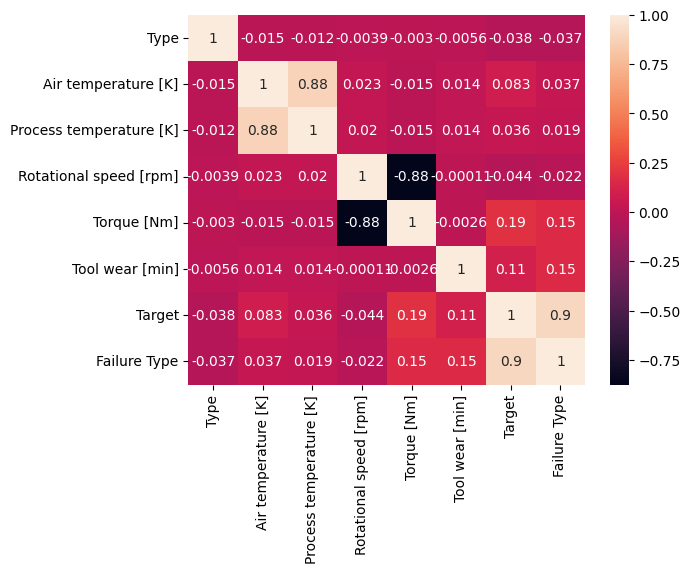

In [15]:
# To find multi-collinearity present in the data
sns.heatmap(data.corr(),annot=True)

NOTE:- 

1. The variables Target and Failure Type are highly correlated, and since they are the target variables for our model, these variables will be combined into a single variable.
2. Preocess Temperature [K] and Air Temperature [K] are positively correlated.
3. Torque [Nm] and Rotational speed [rpm] are negatively correlated.

In [16]:
# merge variables target
data['TargetFailure'] = data['Target'].astype('str') + '-' + data['Failure Type'].astype('str')

# enconding in variable TargetFailure
code_failure = {'0-0': 0,'1-1': 1,'1-2': 2,'1-3': 3,'1-4': 4}

data['TargetFailure'] = data['TargetFailure'].map(code_failure)

Feature Selection

In [17]:
# variable target 
X = data.drop(columns = ['TargetFailure'])
y = data[['TargetFailure']]

# Scaling the data
x = StandardScaler().fit_transform(X)

In [18]:
# Training splitting and testing data
x_train , x_test ,y_train ,y_test = train_test_split(x,y ,test_size=0.2 ,random_state=42)

Cross validation technique

In [19]:
svm_classifier = SVC(kernel='linear')
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
cross_val_results = cross_val_score(svm_classifier, x, y, cv=kf)
print(f'Cross-Validation Results (Accuracy): {cross_val_results}')
print(f'Mean Accuracy: {cross_val_results.mean()}')

Cross-Validation Results (Accuracy): [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


MODELING

Choosing Algorithms

In [20]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machine': SVC(),
}

Evaluaion

Decision Tree accuracy: 1.00
Random Forest accuracy: 1.00
K-Nearest Neighbors accuracy: 1.00
Logistic Regression accuracy: 1.00
Support Vector Machine accuracy: 1.00


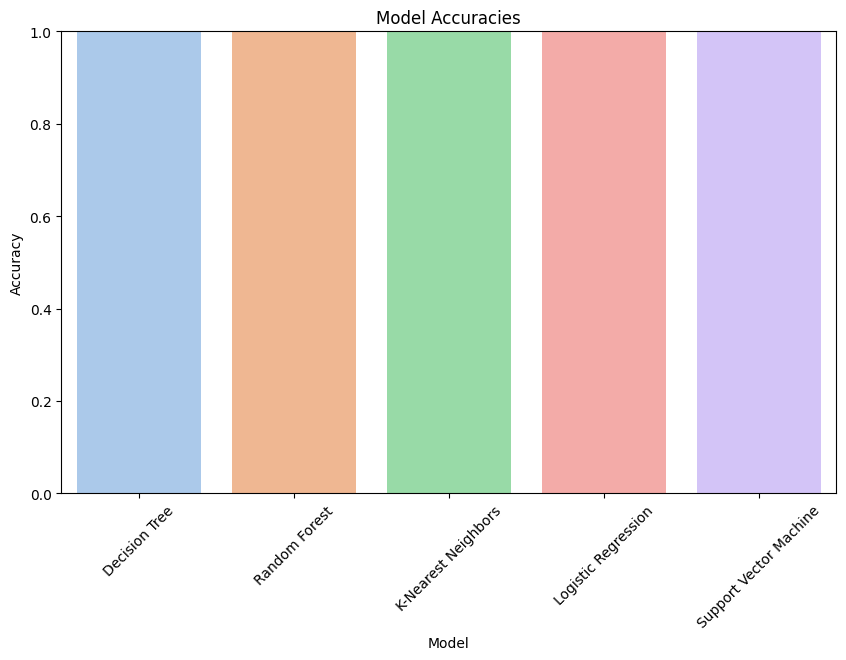

In [21]:
model_names = []
accuracies = []

for name, clf in models.items():
    clf.fit(x_train, y_train)
    score = clf.score(x_test, y_test)  
    model_names.append(name)
    accuracies.append(score)
    print(f"{name} accuracy: {score:.2f}")

df_models = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_models,palette='pastel')
plt.title('Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

In [22]:
for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    y_pred = model.predict(x_test)  
    print("Classification Report:")
    print(classification_report(y_test, y_pred))  
    plt.show()

Evaluating Decision Tree...
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1936
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        23
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         5

    accuracy                           1.00      1995
   macro avg       1.00      1.00      1.00      1995
weighted avg       1.00      1.00      1.00      1995

Evaluating Random Forest...
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1936
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        23
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         5

    accuracy                           1.00      1995
   macro avg       1.00      

Confusion Marices

In [23]:
for name, model in models.items():
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n{cm}\n")

Confusion Matrix for Decision Tree:
[[1936    0    0    0    0]
 [   0   23    0    0    0]
 [   0    0   23    0    0]
 [   0    0    0    8    0]
 [   0    0    0    0    5]]



Confusion Matrix for Random Forest:
[[1936    0    0    0    0]
 [   0   23    0    0    0]
 [   0    0   23    0    0]
 [   0    0    0    8    0]
 [   0    0    0    0    5]]

Confusion Matrix for K-Nearest Neighbors:
[[1936    0    0    0    0]
 [   0   23    0    0    0]
 [   0    0   23    0    0]
 [   0    0    0    8    0]
 [   0    0    0    0    5]]

Confusion Matrix for Logistic Regression:
[[1936    0    0    0    0]
 [   0   23    0    0    0]
 [   0    0   23    0    0]
 [   0    0    0    8    0]
 [   0    0    0    0    5]]

Confusion Matrix for Support Vector Machine:
[[1936    0    0    0    0]
 [   0   23    0    0    0]
 [   0    0   23    0    0]
 [   0    0    0    8    0]
 [   0    0    0    0    5]]



Predicted Values

In [24]:
for name, model in models.items():
    y_pred = model.predict(x_test)
    print(f"Predicted values for {name}:\n{y_pred}\n")

Predicted values for Decision Tree:
[0 0 1 ... 0 0 0]

Predicted values for Random Forest:
[0 0 1 ... 0 0 0]

Predicted values for K-Nearest Neighbors:
[0 0 1 ... 0 0 0]

Predicted values for Logistic Regression:
[0 0 1 ... 0 0 0]

Predicted values for Support Vector Machine:
[0 0 1 ... 0 0 0]

